--------------------------------------------------------------------------------
Running test with params: {'r': 0.5, 'num_iterations': 2} | B=1, N=40, C=8

Original shape: torch.Size([1, 40, 8])
Merged shape:   torch.Size([1, 20, 8]) (20 tokens merged)
Unmerged shape: torch.Size([1, 40, 8])
merge_btree (B=0): [ 0 -1 -1  0  0 -1 -1  0 -1 -1  0 -1 -1  0  0  0 -1 -1  0  0  0  0  0 -1
 -1  0  0 -1 -1  0  0 -1 -1  0 -1 -1  0 -1  0 -1]
avg_sim (B=0): 0.7298256158828735
sim: 0.9634724855422974


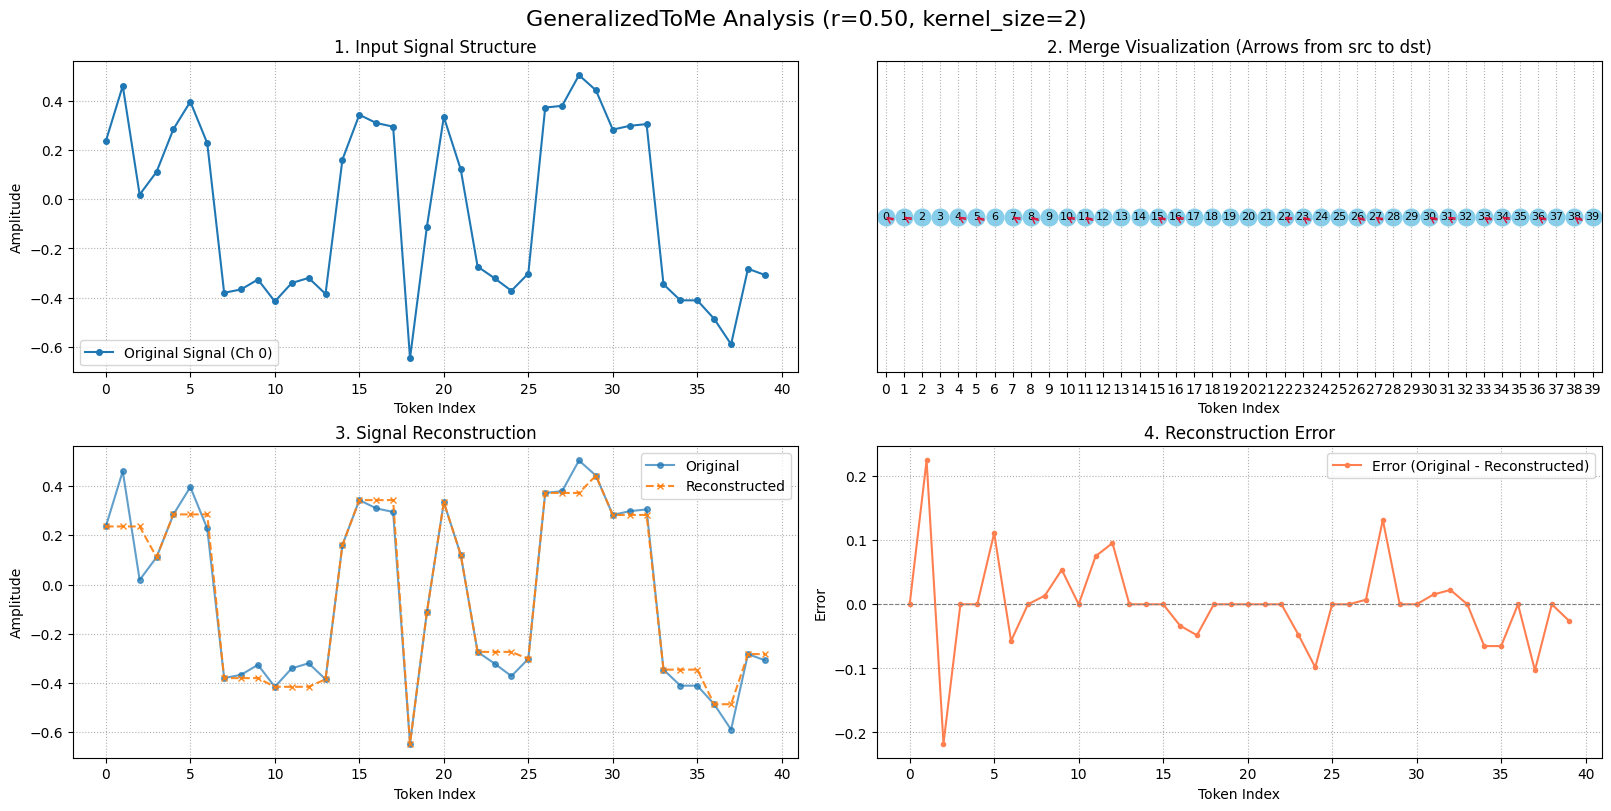

mean error -0.0002600599
--------------------------------------------------------------------------------
Running test with params: {'r': 0.5, 'num_iterations': 4} | B=1, N=40, C=8

Original shape: torch.Size([1, 40, 8])
Merged shape:   torch.Size([1, 20, 8]) (20 tokens merged)
Unmerged shape: torch.Size([1, 40, 8])
merge_btree (B=0): [ 0 -1  0  0  0 -1 -1  0 -1 -1  0  0 -1  0  0 -1 -1 -1  0  0  0  0  0 -1
 -1 -1  0 -1  0  0 -1 -1 -1  0 -1 -1 -1  0  0 -1]
avg_sim (B=0): 0.8810949325561523
sim: 0.9701347351074219


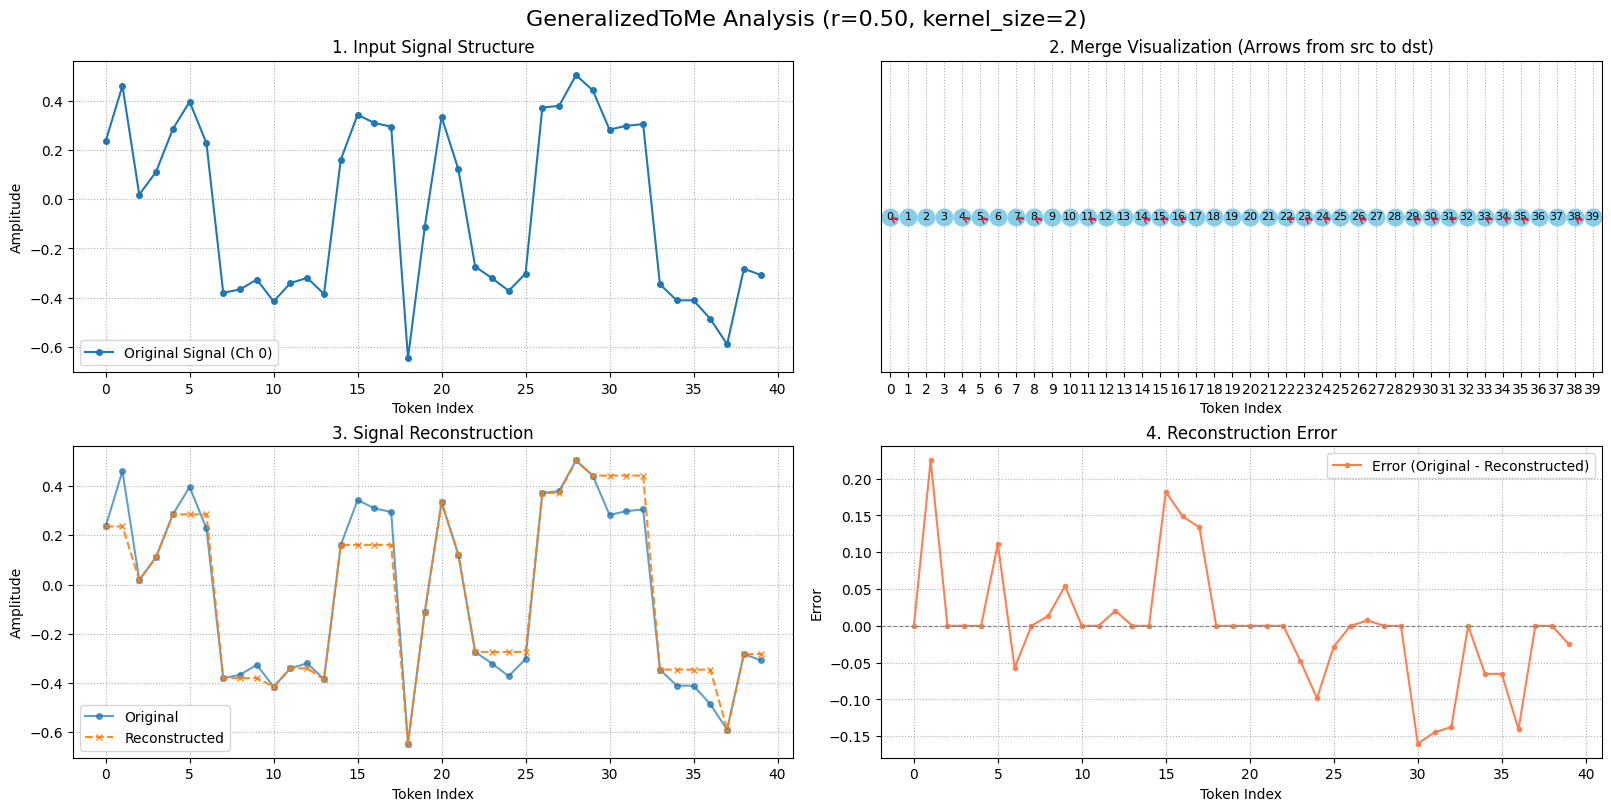

mean error -0.0018579133
--------------------------------------------------------------------------------
Running test with params: {'r': 0.5, 'num_iterations': 8} | B=1, N=40, C=8

Original shape: torch.Size([1, 40, 8])
Merged shape:   torch.Size([1, 20, 8]) (20 tokens merged)
Unmerged shape: torch.Size([1, 40, 8])
merge_btree (B=0): [ 0 -1  0  0  0 -1 -1  0 -1 -1  0  0 -1  0  0 -1 -1 -1  0  0  0  0  0 -1
 -1  0  0 -1  0  0 -1 -1 -1  0 -1 -1 -1 -1  0 -1]
avg_sim (B=0): 0.8991730213165283
sim: 0.9705867767333984


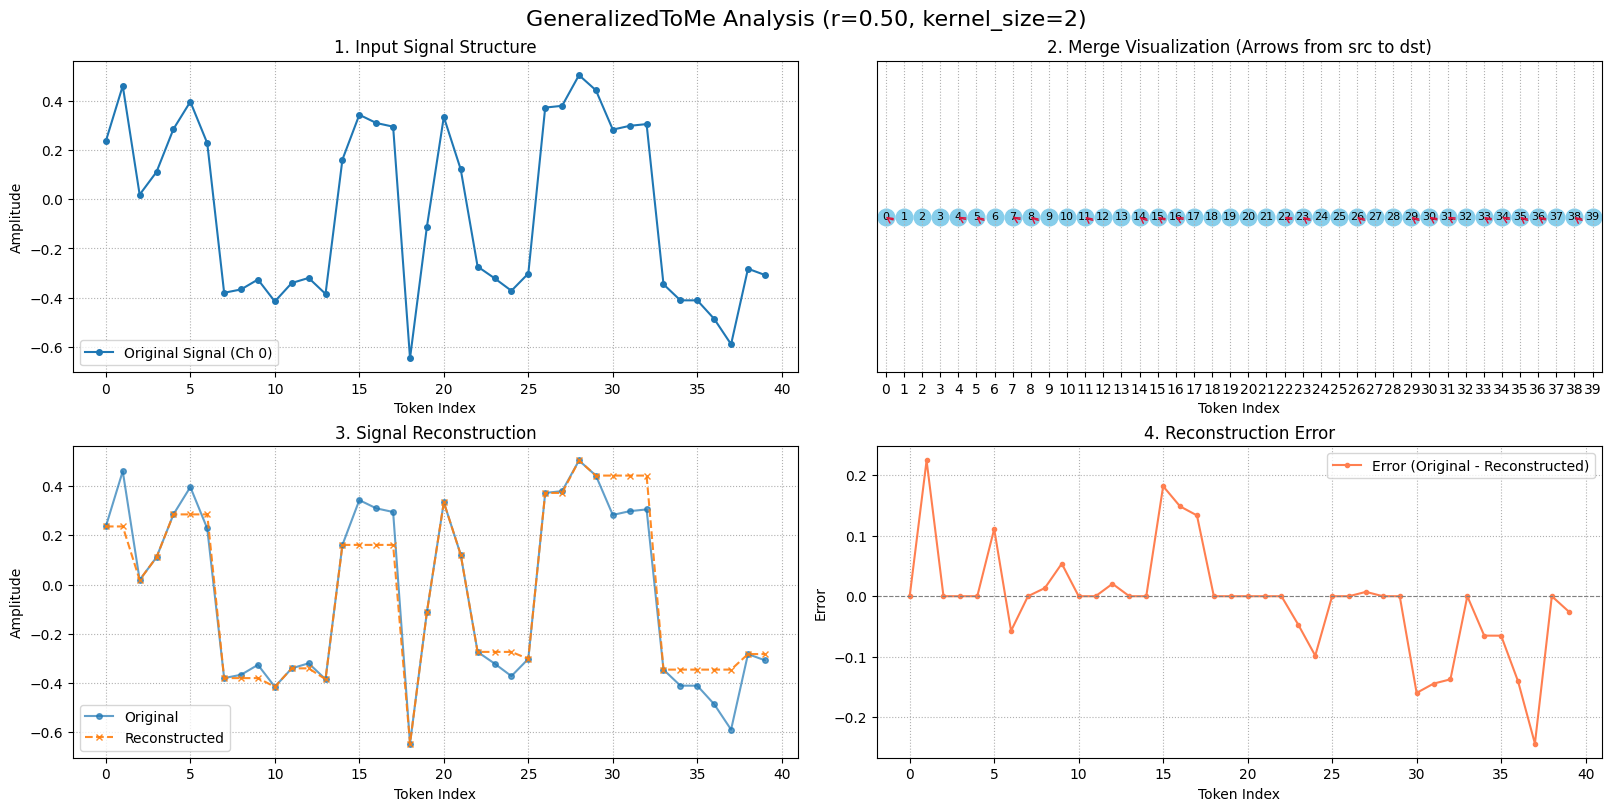

mean error -0.0072425455
--------------------------------------------------------------------------------
Running test with params: {'r': 0.5, 'num_iterations': 16} | B=1, N=40, C=8

Original shape: torch.Size([1, 40, 8])
Merged shape:   torch.Size([1, 20, 8]) (20 tokens merged)
Unmerged shape: torch.Size([1, 40, 8])
merge_btree (B=0): [ 0 -1  0  0  0 -1 -1  0 -1 -1  0  0 -1  0  0 -1 -1 -1  0  0  0  0  0 -1
 -1  0  0 -1  0  0 -1 -1 -1  0 -1 -1 -1 -1  0 -1]
avg_sim (B=0): 0.8991730213165283
sim: 0.9705867767333984


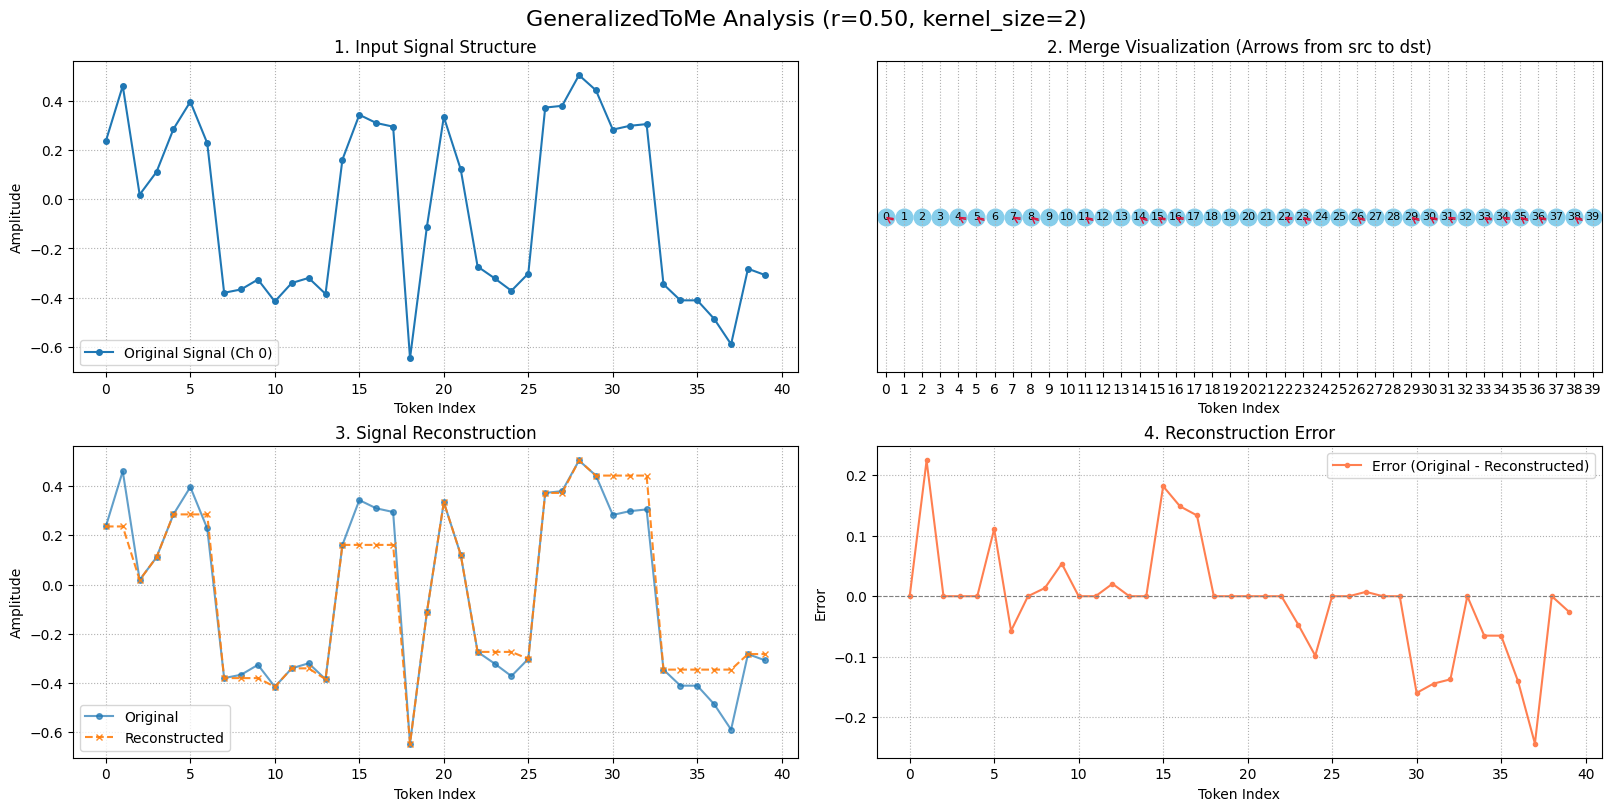

mean error -0.0072425455


In [9]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tome_ops import ToPrK2New, ToPrPLETopK, ToPrCPRRTopK
from typing import Dict

# Ensure tome_ops.py is in your Python path or the same directory.
# You might need to restart your kernel to see changes in tome_ops.py.

def generate_test_signal(N: int, num_channels: int = 4, batch_size: int = 2) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Generates a realistic test signal of shape (B, N, C).
    Each sample has a base sinusoidal structure with added per-channel noise.
    """
    torch.manual_seed(2)  # for reproducibility
    
    batch_tensors = []
    for b in range(batch_size):
        # 1. Create a base signal. Add a small offset per batch item for variety.
        t = torch.linspace(0, 6 * np.pi, N)
        base_signal = torch.sin(t + b * 0.5) * 0.8 + torch.cos((t + b * 0.2) * 2.5) * 0.6
        
        # 2. Create C channels, each with its own unique noise
        channels = []
        for _ in range(num_channels):
            noise = torch.randn(N) * 0.15 # Add modest noise
            channel_signal = base_signal + noise
            channels.append(channel_signal)
        
        # 3. Stack channels to create one sample of shape (N, C)
        sample = torch.stack(channels, dim=-1)
        batch_tensors.append(sample)

    # 4. Stack all samples to create the final tensor of shape (B, N, C)
    x = torch.stack(batch_tensors, dim=0)
    x = torch.nn.functional.normalize(x, dim=-1)
    # For plotting, use the first channel of the first batch item as a representative
    signal_1d_original = x[0, :, 0].clone()
    
    return x, signal_1d_original

def run_and_visualize_generalized(params: Dict, N: int = 10, C: int = 8, B: int = 1):
    """
    Runs a test case with GeneralizedToMe and visualizes the input signal,
    the merge map, the reconstructed signal, and the reconstruction error.
    """
    print("-" * 80)
    print(f"Running test with params: {params} | B={B}, N={N}, C={C}")
    if B > 1:
        print("(Note: Visualizations will only show the first sample of the batch, i.e., B=0)")
    
    # 1. Generate signal
    x, signal_1d_original = generate_test_signal(N, C, B)
    
    # 2. Instantiate and run the merger
    # We call merge and unmerge separately to get the intermediate btree for visualization.
    # tome = ToMeS_CausalDist(**params)
    # tome = ToMeK2(**params)
    # tome = OurToMe2(**params)
    tome = ToPrK2New(**params)
    # tome = ToMeTopK(**params, filter_chained=True, filter_multiple_src=False)
    merged_x, merge_btree, avg_sim = tome.compute_merge(x.clone())
    merge_map = tome.btree_to_root_map(merge_btree)
    unmerged_x = tome.unmerge(merged_x, merge_map)
    # merge_btree = tome.merge_map_to_btree(merge_map)

    print(f"\nOriginal shape: {x.shape}")
    print(f"Merged shape:   {merged_x.shape} ({x.shape[1] - merged_x.shape[1]} tokens merged)")
    print(f"Unmerged shape: {unmerged_x.shape}")
    print(f"merge_btree (B=0): {merge_btree[0].numpy()}")
    print(f"avg_sim (B=0): {avg_sim.mean().numpy()}")
    similarity = torch.nn.functional.cosine_similarity(unmerged_x, x.clone(), dim=-1)
    print(f"sim: {similarity.mean().numpy()}")

    # 3. Visualization
    fig, axs = plt.subplots(2, 2, figsize=(16, 8), constrained_layout=True)
    title_params = f"r={params.get('r', 0):.2f}, kernel_size={params.get('kernel_size', 2)}"
    fig.suptitle(f"GeneralizedToMe Analysis ({title_params})", fontsize=16)

    # --- Plot 1: Input Signal ---
    axs[0, 0].plot(signal_1d_original.numpy(), marker='o', linestyle='-', markersize=4, label="Original Signal (Ch 0)")
    axs[0, 0].set_title("1. Input Signal Structure")
    axs[0, 0].set_xlabel("Token Index")
    axs[0, 0].set_ylabel("Amplitude")
    axs[0, 0].grid(True, linestyle=':')
    axs[0, 0].legend()

    # --- Plot 2: Merge Visualization ---
    y_pos = 0.5
    axs[0, 1].plot(np.arange(N), np.full(N, y_pos), 'o', markersize=12, color='skyblue', zorder=1)
    for i in range(N):
        axs[0, 1].text(i, y_pos, str(i), ha='center', va='center', color='black', fontsize=8, zorder=2)
    
    for i in range(N):
        offset = merge_btree[0, i].item()
        if offset != 0:
            dst_idx = i + offset
            axs[0, 1].annotate("", xy=(dst_idx, y_pos), xytext=(i, y_pos),
                               arrowprops=dict(arrowstyle="->", color="crimson", shrinkA=8, shrinkB=8,
                                               connectionstyle=f"arc3,rad={-0.4 + (i%3)*0.05}"))
    axs[0, 1].set_title("2. Merge Visualization (Arrows from src to dst)")
    axs[0, 1].set_yticks([])
    axs[0, 1].set_xticks(np.arange(N))
    axs[0, 1].set_xlabel("Token Index")
    axs[0, 1].set_xlim(-0.5, N - 0.5)
    axs[0, 1].grid(axis='x', linestyle=':')

    # --- Plot 3: Reconstructed Signal ---
    signal_1d_unmerged = unmerged_x[0, :, 0].detach().numpy()
    axs[1, 0].plot(signal_1d_original.numpy(), marker='o', linestyle='-', markersize=4, label="Original", alpha=0.7)
    axs[1, 0].plot(signal_1d_unmerged, marker='x', linestyle='--', markersize=5, label="Reconstructed", alpha=0.9)
    axs[1, 0].set_title("3. Signal Reconstruction")
    axs[1, 0].set_xlabel("Token Index")
    axs[1, 0].set_ylabel("Amplitude")
    axs[1, 0].grid(True, linestyle=':')
    axs[1, 0].legend()

    # --- Plot 4: Reconstruction Error ---
    error = (signal_1d_original - torch.from_numpy(signal_1d_unmerged)).numpy()
    axs[1, 1].plot(error, marker='.', linestyle='-', color='coral', label='Error (Original - Reconstructed)')
    axs[1, 1].axhline(0, color='grey', linewidth=0.8, linestyle='--')
    axs[1, 1].set_title("4. Reconstruction Error")
    axs[1, 1].set_xlabel("Token Index")
    axs[1, 1].set_ylabel("Error")
    axs[1, 1].grid(True, linestyle=':')
    axs[1, 1].legend()

    plt.show()

    print('mean error', error.mean())


# --- Example Test Cases ---

# # # Case 1: High reduction rate, small kernel. Many local merges are expected.
run_and_visualize_generalized(params={"r": 0.5, "num_iterations": 2}, N=40)

# # Case 2: High reduction rate, large kernel. Merges can span longer distances.
run_and_visualize_generalized(params={"r": 0.5, "num_iterations": 4}, N=40)

# # Case 3: Low reduction rate, medium kernel. Only the most similar pairs should merge.
run_and_visualize_generalized(params={"r": 0.5,  "num_iterations": 8}, N=40)


run_and_visualize_generalized(params={"r": 0.5,  "num_iterations": 16}, N=40)




--------------------------------------------------------------------------------
Running test with params: {'r': 0.5, 'bin_size': 4} | B=1, N=40, C=8

Original shape: torch.Size([1, 40, 8])
Merged shape:   torch.Size([1, 20, 8]) (20 tokens merged)
Unmerged shape: torch.Size([1, 40, 8])
merge_btree (B=0): [ 0  0  0 -1 -1 -1  0 -1 -1  0  0 -1  0  0  0 -1 -1  0  0  0  0  0  0 -1
  0  0 -1 -1  0 -1 -1 -1  0 -1 -1 -1 -1  0 -1 -1]
avg_sim (B=0): 0.02507251501083374
sim: 0.5411036610603333


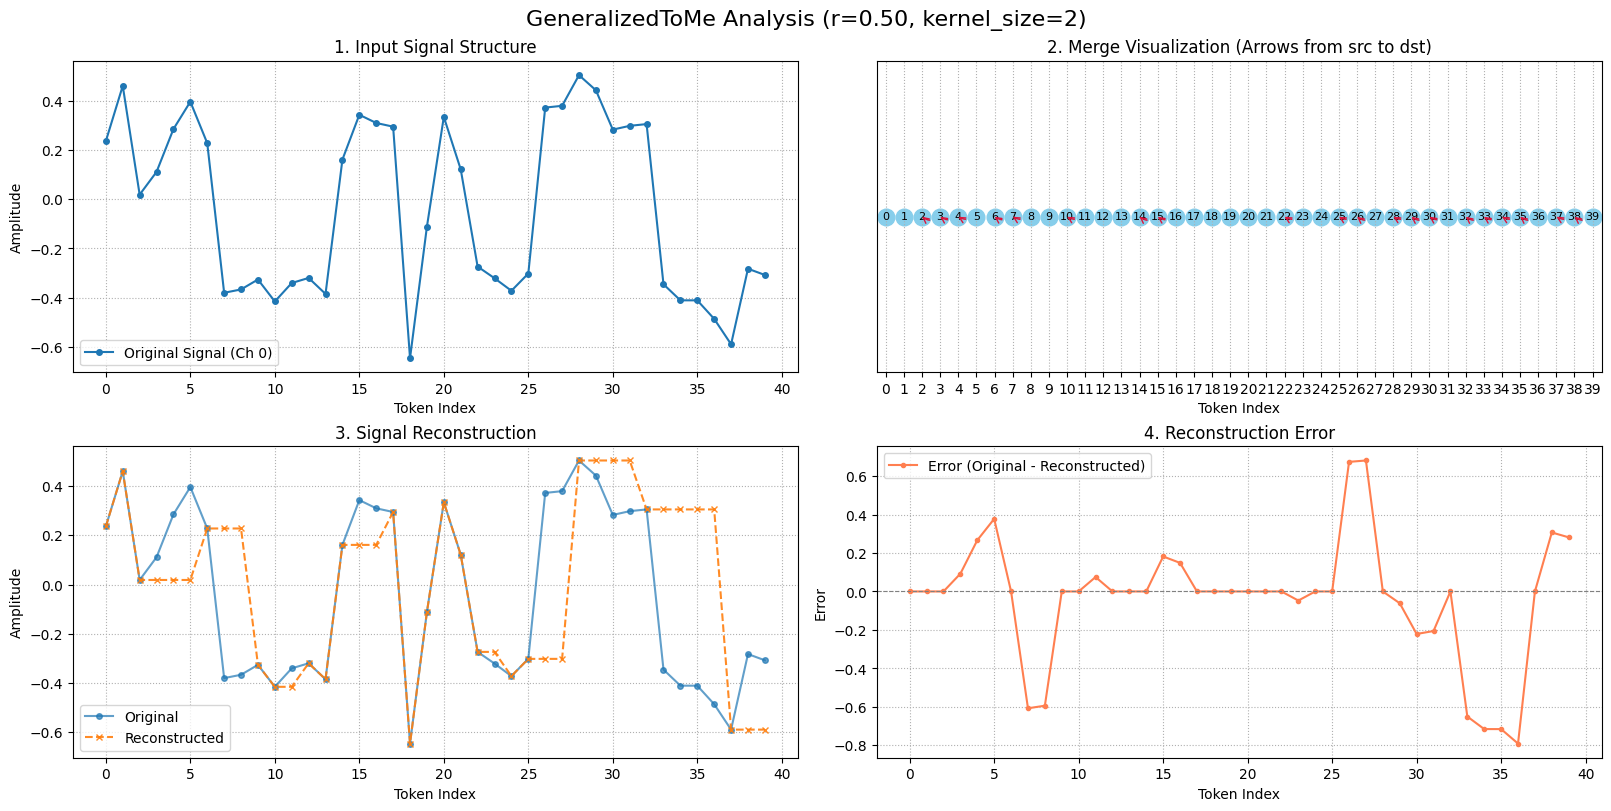

mean error -0.038144875
--------------------------------------------------------------------------------
Running test with params: {'r': 0.5, 'bin_size': 8} | B=1, N=40, C=8

Original shape: torch.Size([1, 40, 8])
Merged shape:   torch.Size([1, 20, 8]) (20 tokens merged)
Unmerged shape: torch.Size([1, 40, 8])
merge_btree (B=0): [ 0  0  0  0 -1 -1  0 -1 -1 -1  0 -1  0  0 -1 -1 -1  0  0  0  0  0  0  0
  0  0 -1  0  0 -1 -1 -1  0 -1 -1 -1 -1 -1 -1 -1]
avg_sim (B=0): 0.004701972007751465
sim: 0.28574639558792114


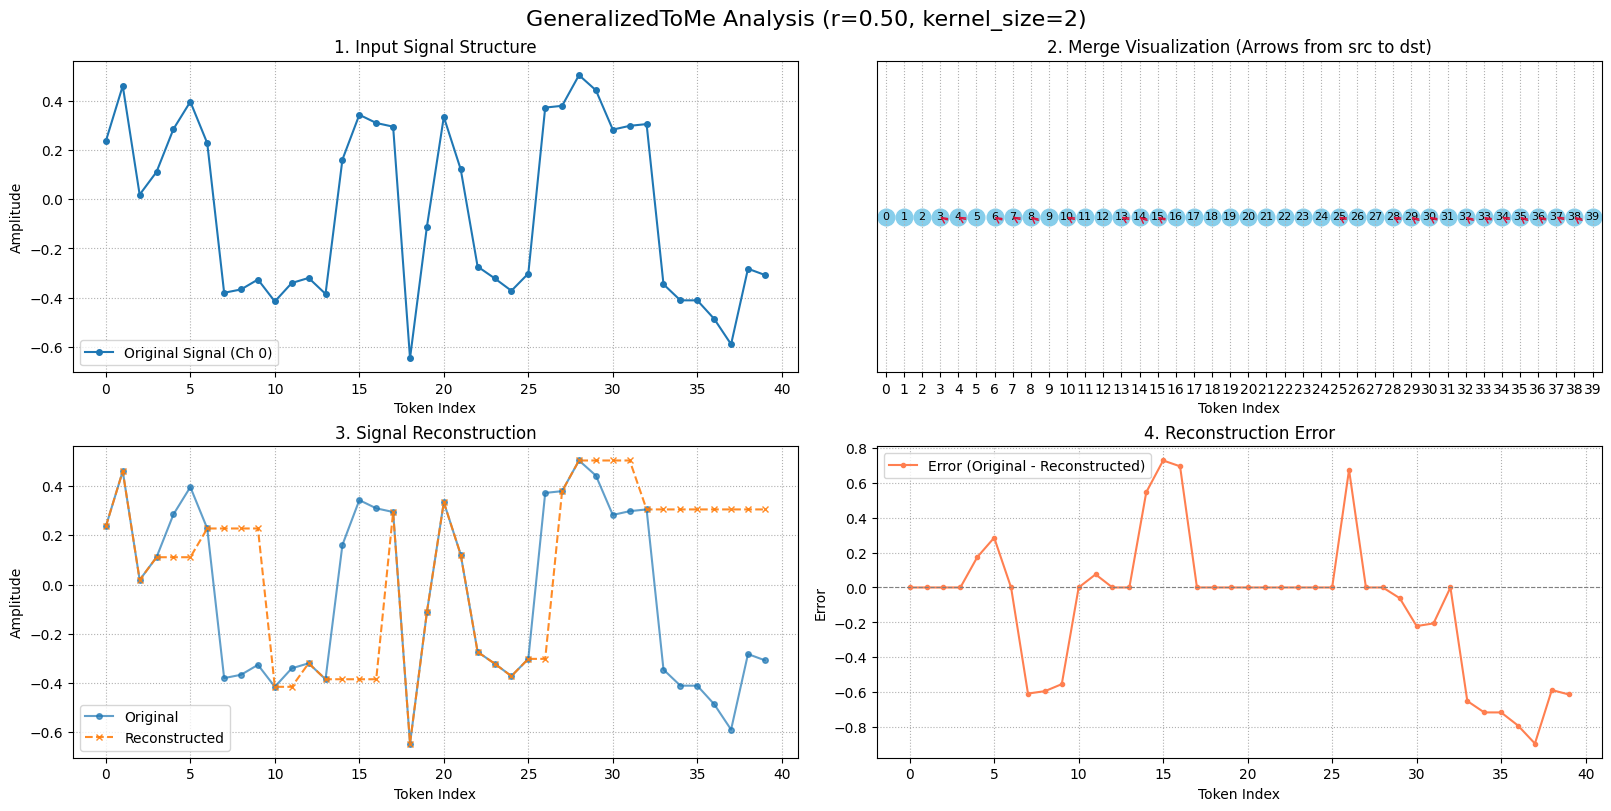

mean error -0.100921154
--------------------------------------------------------------------------------
Running test with params: {'r': 0.5, 'bin_size': 16} | B=1, N=40, C=8

Original shape: torch.Size([1, 40, 8])
Merged shape:   torch.Size([1, 20, 8]) (20 tokens merged)
Unmerged shape: torch.Size([1, 40, 8])
merge_btree (B=0): [ 0  0  0  0 -1 -1  0 -1 -1 -1  0 -1 -1  0 -1  0  0  0  0  0  0  0 -1 -1
 -1  0 -1  0  0 -1 -1 -1  0 -1 -1 -1  0  0 -1 -1]
avg_sim (B=0): 0.01990419626235962
sim: 0.43166613578796387


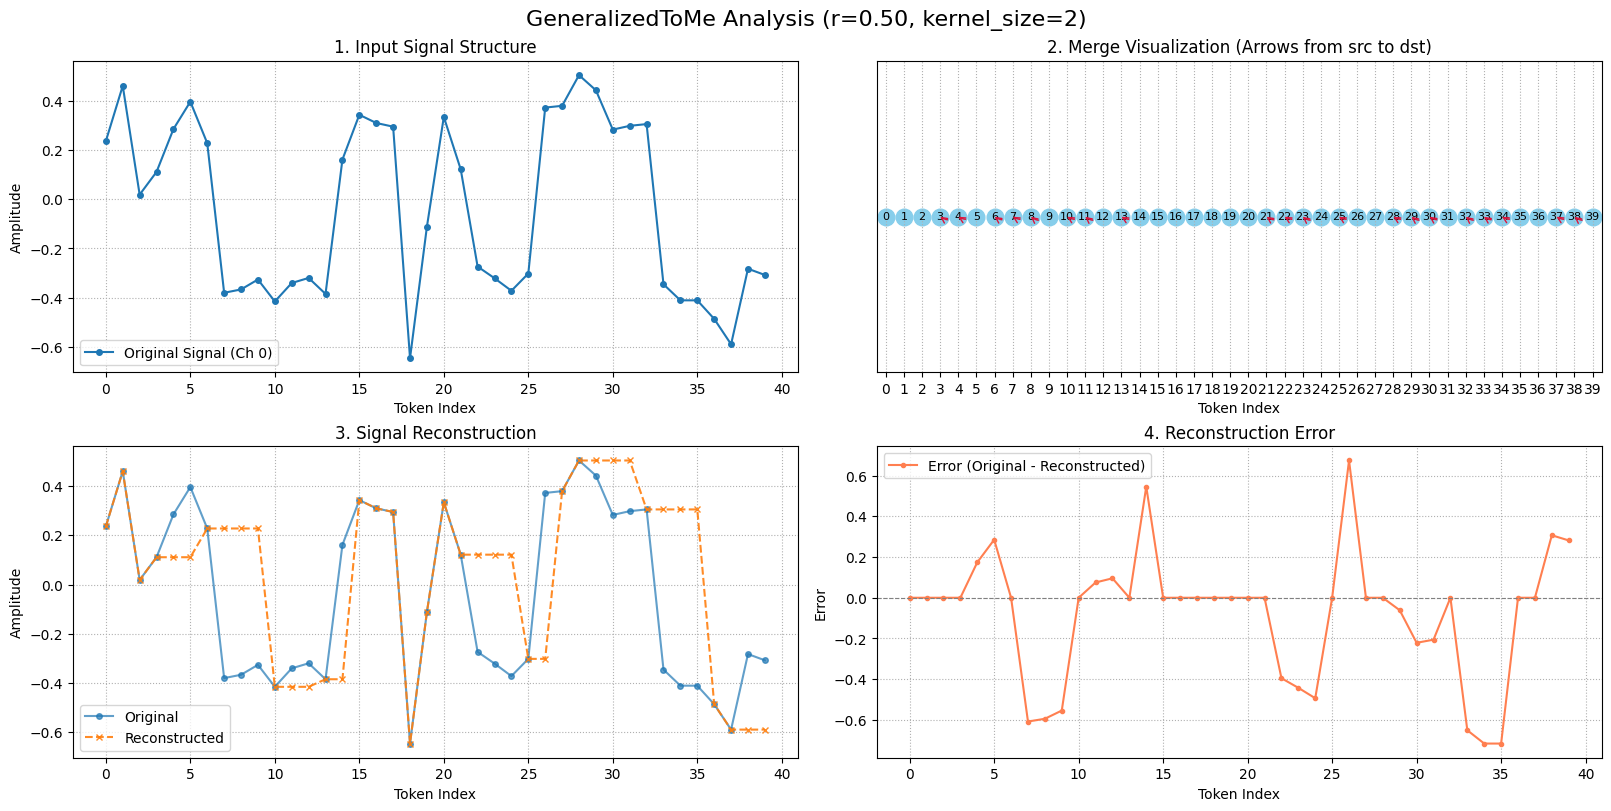

mean error -0.080483496
--------------------------------------------------------------------------------
Running test with params: {'r': 0.5, 'bin_size': 16, 'beta': 0.3} | B=1, N=40, C=8

Original shape: torch.Size([1, 40, 8])
Merged shape:   torch.Size([1, 20, 8]) (20 tokens merged)
Unmerged shape: torch.Size([1, 40, 8])
merge_btree (B=0): [ 0  0  0  0 -1 -1  0 -1 -1 -1  0 -1  0  0  0 -1 -1  0  0  0  0  0 -1 -1
 -1  0 -1  0  0 -1 -1 -1  0 -1 -1 -1  0  0 -1 -1]
avg_sim (B=0): 0.0713663101196289
sim: 0.4790334701538086


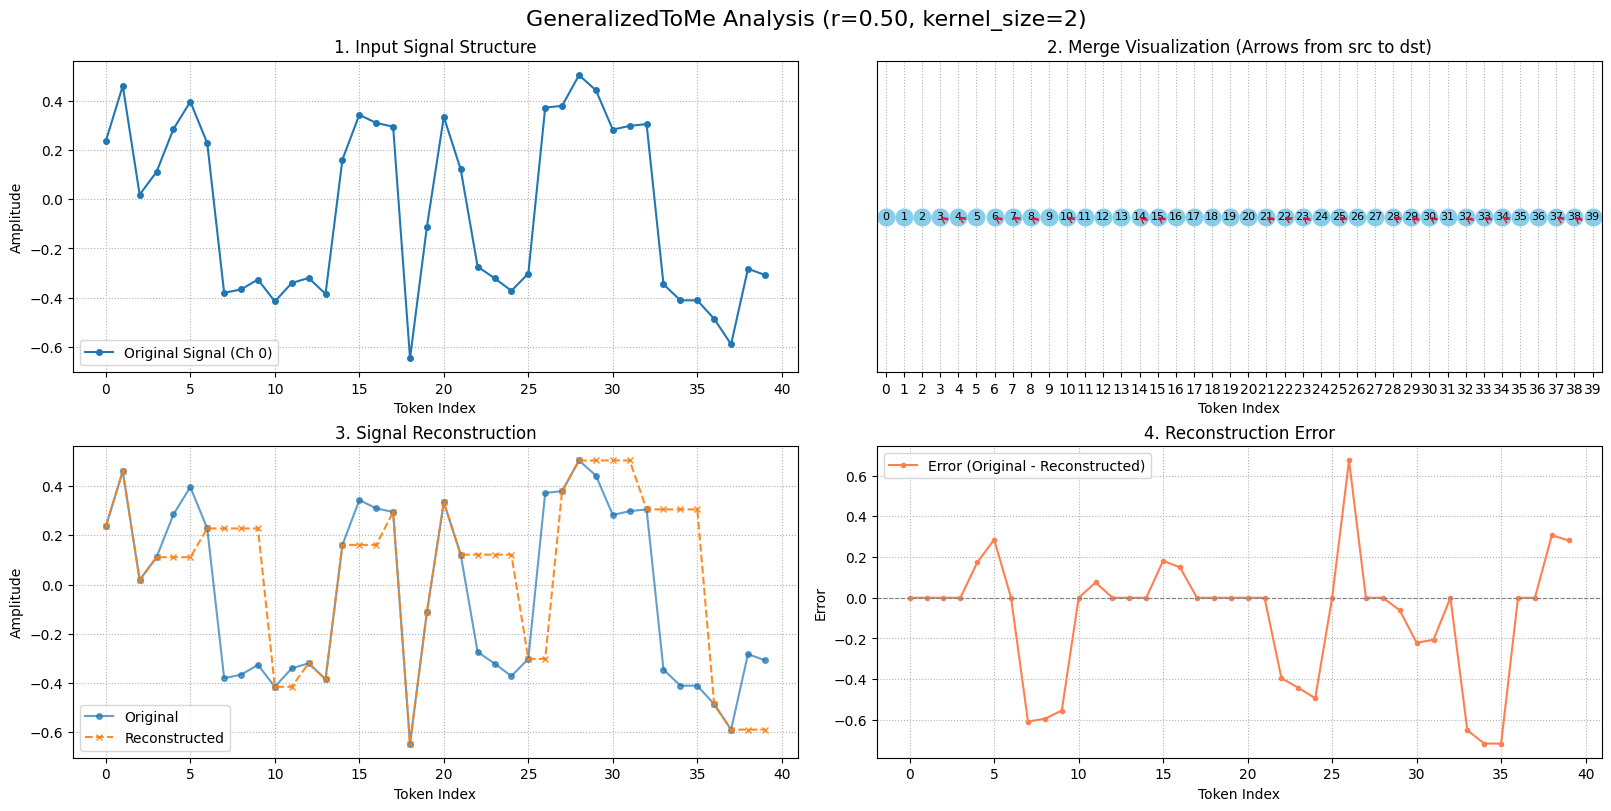

mean error -0.0882511


In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tome_ops import ToPrK2New, ToPrPLETopK, ToPrCPRRTopK
from typing import Dict

# Ensure tome_ops.py is in your Python path or the same directory.
# You might need to restart your kernel to see changes in tome_ops.py.

def generate_test_signal(N: int, num_channels: int = 4, batch_size: int = 2) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Generates a realistic test signal of shape (B, N, C).
    Each sample has a base sinusoidal structure with added per-channel noise.
    """
    torch.manual_seed(2)  # for reproducibility
    
    batch_tensors = []
    for b in range(batch_size):
        # 1. Create a base signal. Add a small offset per batch item for variety.
        t = torch.linspace(0, 6 * np.pi, N)
        base_signal = torch.sin(t + b * 0.5) * 0.8 + torch.cos((t + b * 0.2) * 2.5) * 0.6
        
        # 2. Create C channels, each with its own unique noise
        channels = []
        for _ in range(num_channels):
            noise = torch.randn(N) * 0.15 # Add modest noise
            channel_signal = base_signal + noise
            channels.append(channel_signal)
        
        # 3. Stack channels to create one sample of shape (N, C)
        sample = torch.stack(channels, dim=-1)
        batch_tensors.append(sample)

    # 4. Stack all samples to create the final tensor of shape (B, N, C)
    x = torch.stack(batch_tensors, dim=0)
    x = torch.nn.functional.normalize(x, dim=-1)
    # For plotting, use the first channel of the first batch item as a representative
    signal_1d_original = x[0, :, 0].clone()
    
    return x, signal_1d_original

def run_and_visualize_generalized(params: Dict, N: int = 10, C: int = 8, B: int = 1):
    """
    Runs a test case with GeneralizedToMe and visualizes the input signal,
    the merge map, the reconstructed signal, and the reconstruction error.
    """
    print("-" * 80)
    print(f"Running test with params: {params} | B={B}, N={N}, C={C}")
    if B > 1:
        print("(Note: Visualizations will only show the first sample of the batch, i.e., B=0)")
    
    # 1. Generate signal
    x, signal_1d_original = generate_test_signal(N, C, B)
    
    # 2. Instantiate and run the merger
    # We call merge and unmerge separately to get the intermediate btree for visualization.
    # tome = ToMeS_CausalDist(**params)
    # tome = ToMeK2(**params)
    # tome = OurToMe2(**params)
    tome = ToPrCPRRTopK(**params)
    # tome = ToMeTopK(**params, filter_chained=True, filter_multiple_src=False)
    merged_x, merge_btree, avg_sim = tome.compute_merge(x.clone())
    merge_map = tome.btree_to_root_map(merge_btree)
    unmerged_x = tome.unmerge(merged_x, merge_map)
    # merge_btree = tome.merge_map_to_btree(merge_map)

    print(f"\nOriginal shape: {x.shape}")
    print(f"Merged shape:   {merged_x.shape} ({x.shape[1] - merged_x.shape[1]} tokens merged)")
    print(f"Unmerged shape: {unmerged_x.shape}")
    print(f"merge_btree (B=0): {merge_btree[0].numpy()}")
    print(f"avg_sim (B=0): {avg_sim.mean().numpy()}")
    similarity = torch.nn.functional.cosine_similarity(unmerged_x, x.clone(), dim=-1)
    print(f"sim: {similarity.mean().numpy()}")

    # 3. Visualization
    fig, axs = plt.subplots(2, 2, figsize=(16, 8), constrained_layout=True)
    title_params = f"r={params.get('r', 0):.2f}, kernel_size={params.get('kernel_size', 2)}"
    fig.suptitle(f"GeneralizedToMe Analysis ({title_params})", fontsize=16)

    # --- Plot 1: Input Signal ---
    axs[0, 0].plot(signal_1d_original.numpy(), marker='o', linestyle='-', markersize=4, label="Original Signal (Ch 0)")
    axs[0, 0].set_title("1. Input Signal Structure")
    axs[0, 0].set_xlabel("Token Index")
    axs[0, 0].set_ylabel("Amplitude")
    axs[0, 0].grid(True, linestyle=':')
    axs[0, 0].legend()

    # --- Plot 2: Merge Visualization ---
    y_pos = 0.5
    axs[0, 1].plot(np.arange(N), np.full(N, y_pos), 'o', markersize=12, color='skyblue', zorder=1)
    for i in range(N):
        axs[0, 1].text(i, y_pos, str(i), ha='center', va='center', color='black', fontsize=8, zorder=2)
    
    for i in range(N):
        offset = merge_btree[0, i].item()
        if offset != 0:
            dst_idx = i + offset
            axs[0, 1].annotate("", xy=(dst_idx, y_pos), xytext=(i, y_pos),
                               arrowprops=dict(arrowstyle="->", color="crimson", shrinkA=8, shrinkB=8,
                                               connectionstyle=f"arc3,rad={-0.4 + (i%3)*0.05}"))
    axs[0, 1].set_title("2. Merge Visualization (Arrows from src to dst)")
    axs[0, 1].set_yticks([])
    axs[0, 1].set_xticks(np.arange(N))
    axs[0, 1].set_xlabel("Token Index")
    axs[0, 1].set_xlim(-0.5, N - 0.5)
    axs[0, 1].grid(axis='x', linestyle=':')

    # --- Plot 3: Reconstructed Signal ---
    signal_1d_unmerged = unmerged_x[0, :, 0].detach().numpy()
    axs[1, 0].plot(signal_1d_original.numpy(), marker='o', linestyle='-', markersize=4, label="Original", alpha=0.7)
    axs[1, 0].plot(signal_1d_unmerged, marker='x', linestyle='--', markersize=5, label="Reconstructed", alpha=0.9)
    axs[1, 0].set_title("3. Signal Reconstruction")
    axs[1, 0].set_xlabel("Token Index")
    axs[1, 0].set_ylabel("Amplitude")
    axs[1, 0].grid(True, linestyle=':')
    axs[1, 0].legend()

    # --- Plot 4: Reconstruction Error ---
    error = (signal_1d_original - torch.from_numpy(signal_1d_unmerged)).numpy()
    axs[1, 1].plot(error, marker='.', linestyle='-', color='coral', label='Error (Original - Reconstructed)')
    axs[1, 1].axhline(0, color='grey', linewidth=0.8, linestyle='--')
    axs[1, 1].set_title("4. Reconstruction Error")
    axs[1, 1].set_xlabel("Token Index")
    axs[1, 1].set_ylabel("Error")
    axs[1, 1].grid(True, linestyle=':')
    axs[1, 1].legend()

    plt.show()

    print('mean error', error.mean())


# --- Example Test Cases ---

# # # Case 1: High reduction rate, small kernel. Many local merges are expected.
run_and_visualize_generalized(params={"r": 0.5, "bin_size": 4}, N=40)

# # Case 2: High reduction rate, large kernel. Merges can span longer distances.
run_and_visualize_generalized(params={"r": 0.5, "bin_size": 8}, N=40)

# # Case 3: Low reduction rate, medium kernel. Only the most similar pairs should merge.
run_and_visualize_generalized(params={"r": 0.5,  "bin_size": 16}, N=40)


run_and_visualize_generalized(params={"r": 0.5,  "bin_size": 16, "beta": 0.3}, N=40)




--------------------------------------------------------------------------------
Running test with params: {'r': 0.5, 'beta': 0.3, 'use_bin_argmax': True} | B=1, N=40, C=8

Original shape: torch.Size([1, 40, 8])
Merged shape:   torch.Size([1, 20, 8]) (20 tokens merged)
Unmerged shape: torch.Size([1, 40, 8])
merge_btree (B=0): [ 0 -1 -1  0  0 -1 -1  0 -1 -1  0  0 -1  0  0 -1 -1 -1  0  0  0  0  0 -1
 -1  0  0 -1 -1  0  0 -1 -1  0 -1 -1  0 -1  0 -1]
avg_sim (B=0): 0.05227941274642944
sim: 0.9633979797363281


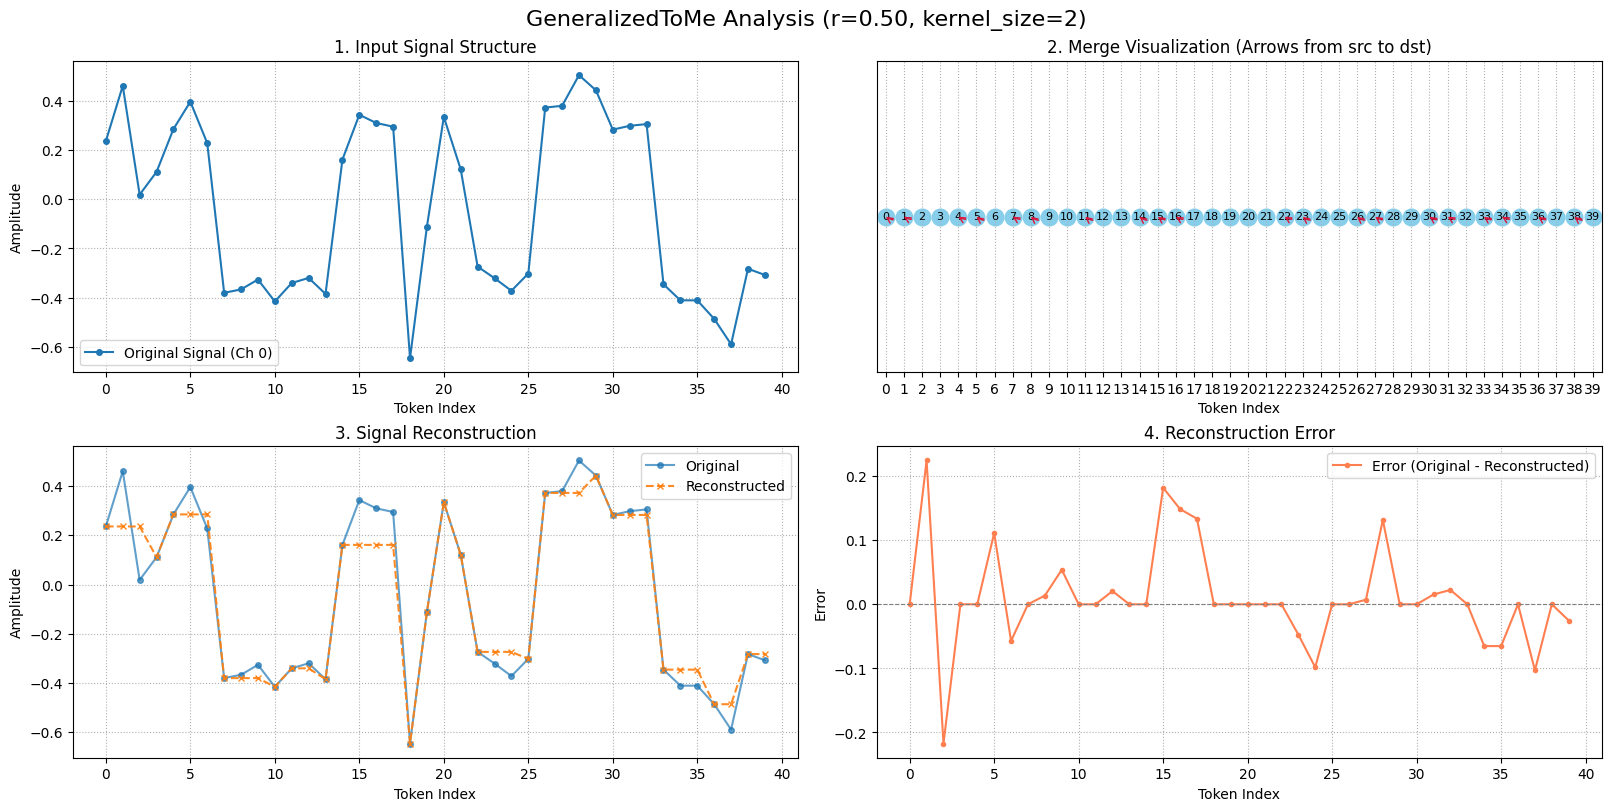

mean error 0.0096351905
--------------------------------------------------------------------------------
Running test with params: {'r': 0.5, 'beta': 1, 'use_bin_argmax': True} | B=1, N=40, C=8

Original shape: torch.Size([1, 40, 8])
Merged shape:   torch.Size([1, 20, 8]) (20 tokens merged)
Unmerged shape: torch.Size([1, 40, 8])
merge_btree (B=0): [ 0  0  0  0  0  0  0  0  0 -1 -1  0 -1 -1  0 -1 -1 -1  0  0  0  0  0 -1
 -1  0  0 -1 -1  0 -1 -1 -1  0 -1 -1 -1 -1 -1 -1]
avg_sim (B=0): 0.02311086654663086
sim: 0.9629451632499695


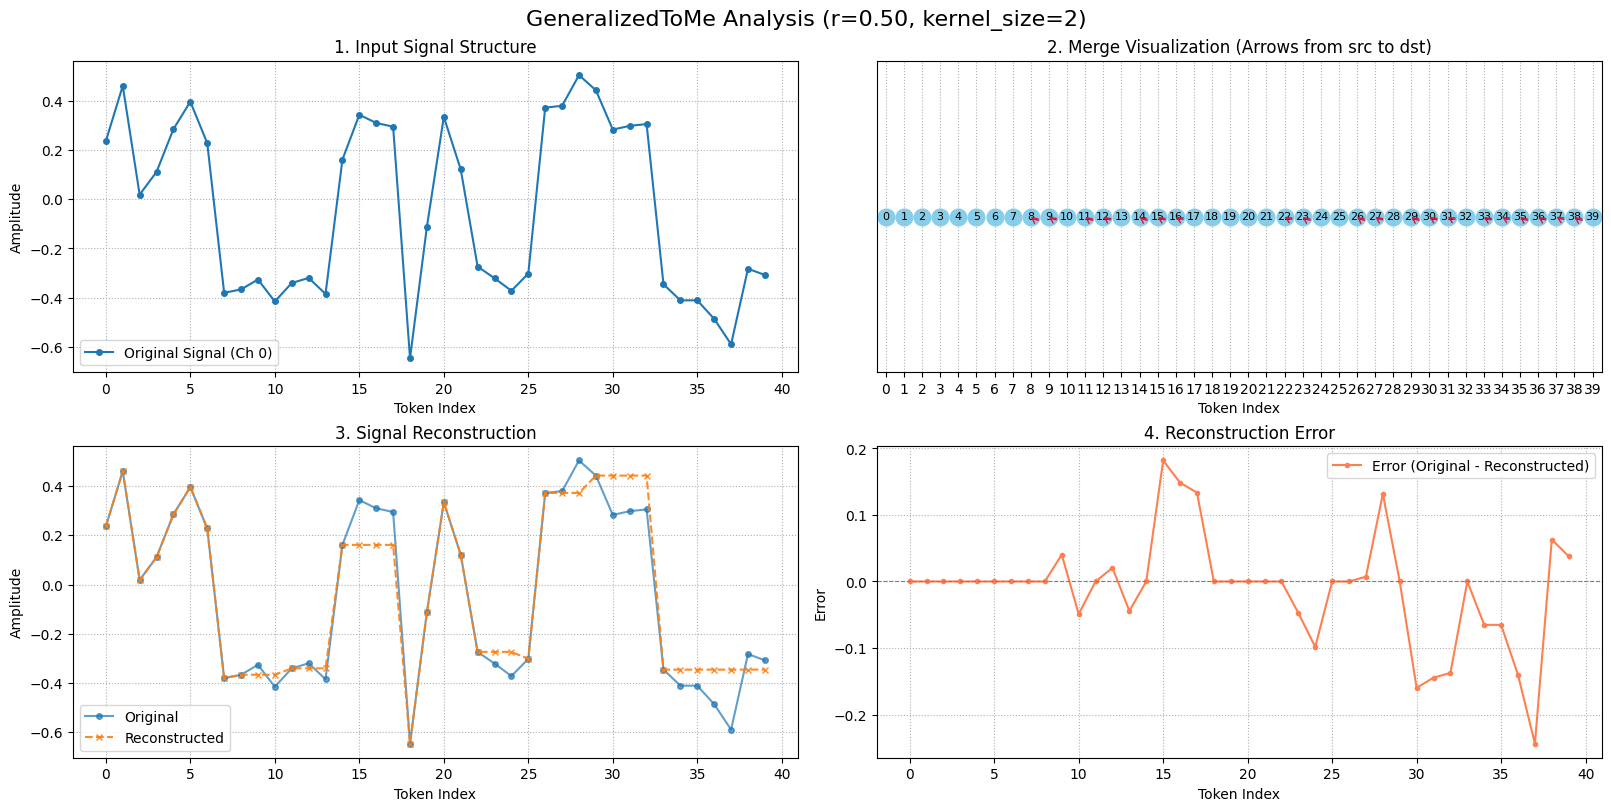

mean error -0.010760272
--------------------------------------------------------------------------------
Running test with params: {'r': 0.5, 'beta': 2, 'use_bin_argmax': True} | B=1, N=40, C=8

Original shape: torch.Size([1, 40, 8])
Merged shape:   torch.Size([1, 20, 8]) (20 tokens merged)
Unmerged shape: torch.Size([1, 40, 8])
merge_btree (B=0): [ 0  0  0  0  0  0  0  0  0  0  0  0  0 -1  0 -1 -1 -1  0  0  0 -1  0 -1
 -1 -1  0 -1 -1 -1 -1 -1 -1  0 -1 -1 -1 -1 -1 -1]
avg_sim (B=0): 0.017084717750549316
sim: 0.9473398327827454


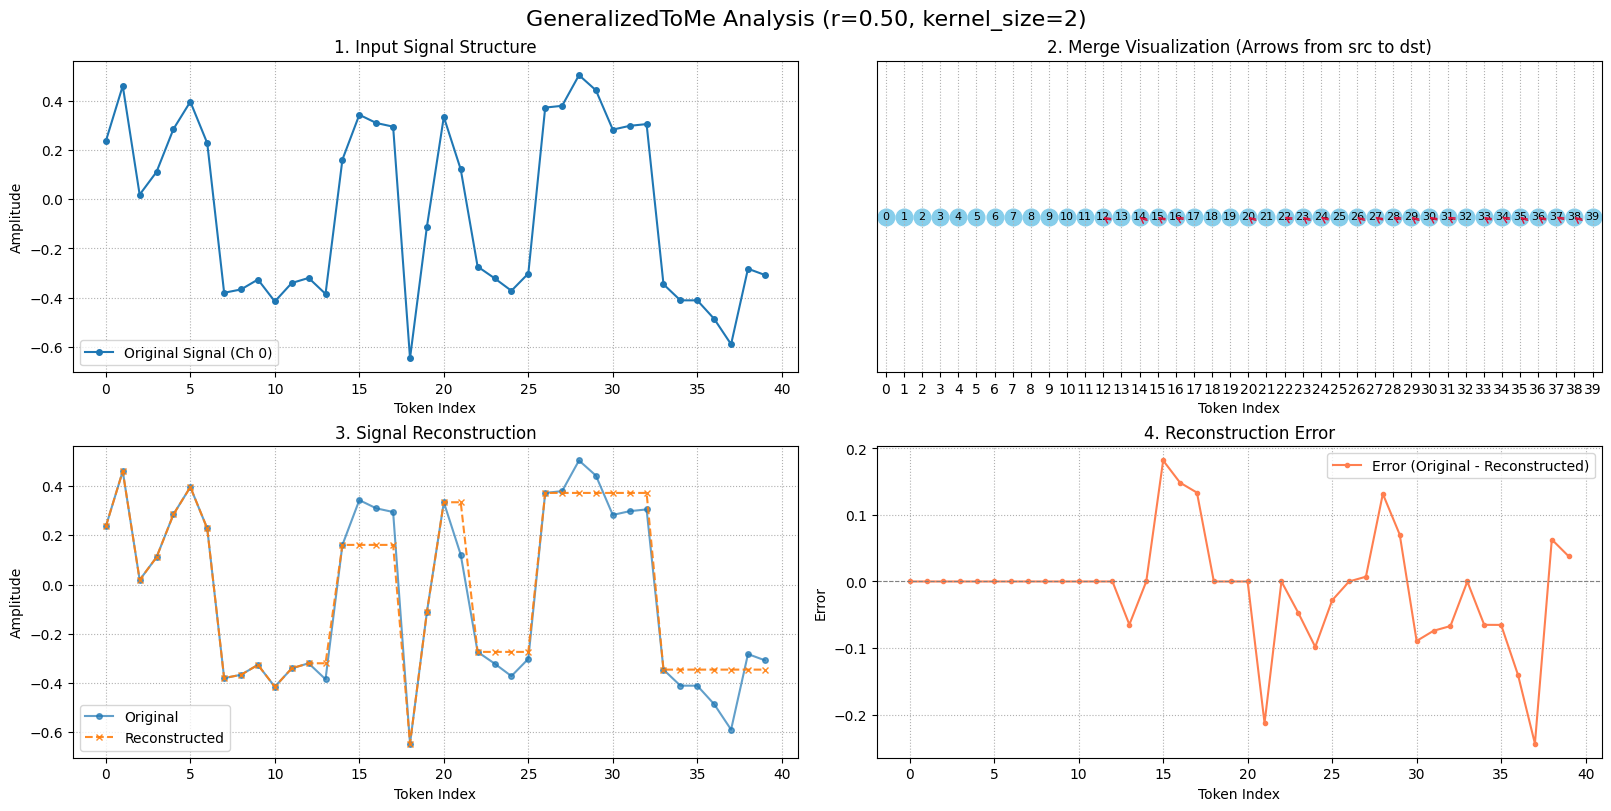

mean error -0.010558184
--------------------------------------------------------------------------------
Running test with params: {'r': 0.5, 'beta': 4, 'use_bin_argmax': True} | B=1, N=40, C=8

Original shape: torch.Size([1, 40, 8])
Merged shape:   torch.Size([1, 20, 8]) (20 tokens merged)
Unmerged shape: torch.Size([1, 40, 8])
merge_btree (B=0): [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1 -1 -1 -1  0  0 -1  0 -1
 -1 -1  0 -1 -1 -1 -1 -1 -1  0 -1 -1 -1 -1 -1 -1]
avg_sim (B=0): 0.017084717750549316
sim: 0.9256387948989868


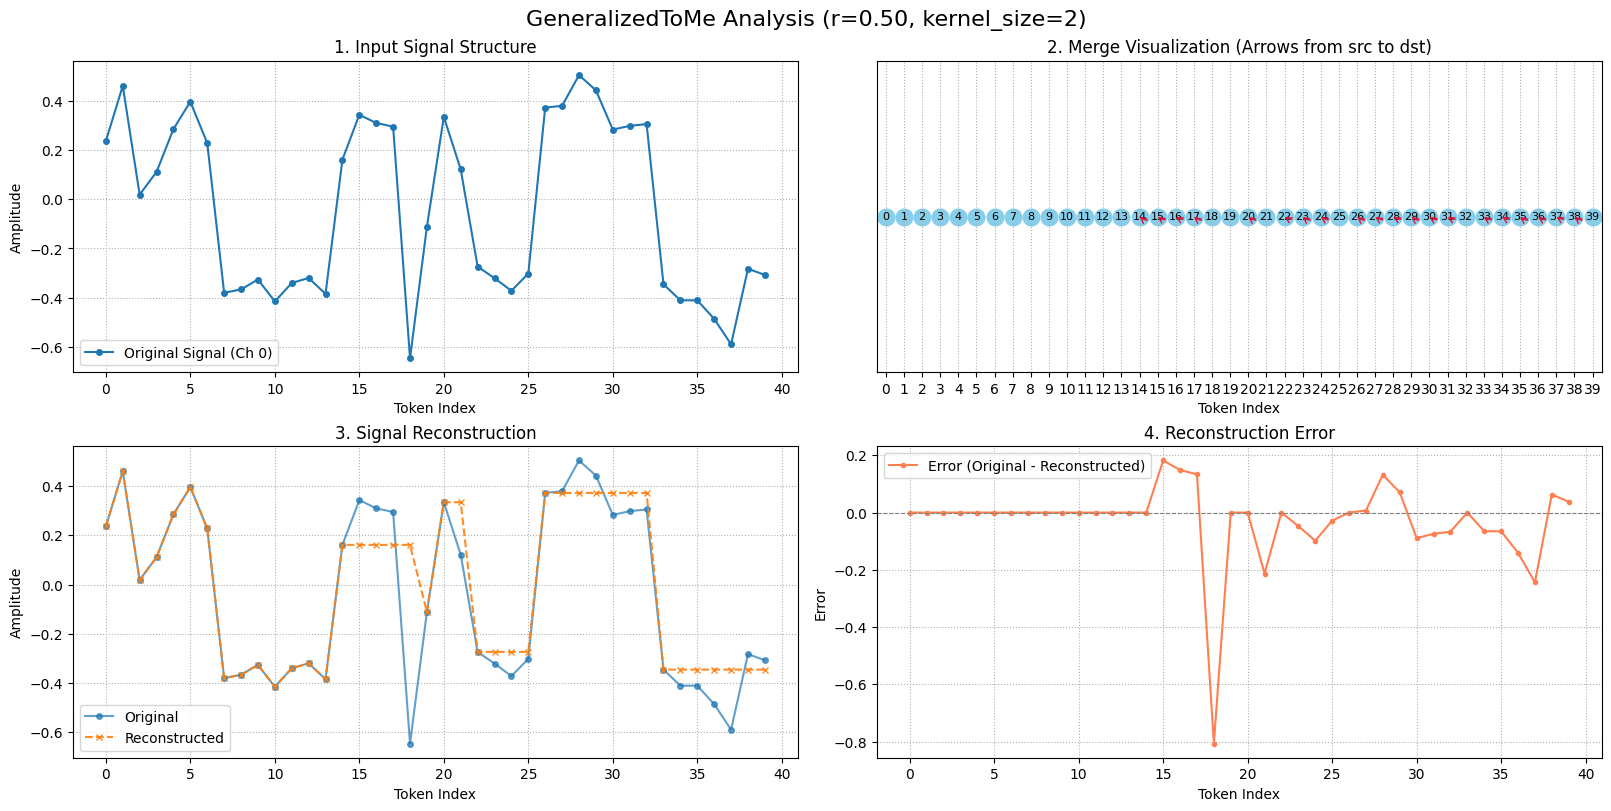

mean error -0.029110655


In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tome_ops import ToPrK2New, ToPrPLETopK, ToPrCPRRTopK
from typing import Dict

# Ensure tome_ops.py is in your Python path or the same directory.
# You might need to restart your kernel to see changes in tome_ops.py.

def generate_test_signal(N: int, num_channels: int = 4, batch_size: int = 2) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Generates a realistic test signal of shape (B, N, C).
    Each sample has a base sinusoidal structure with added per-channel noise.
    """
    torch.manual_seed(2)  # for reproducibility
    
    batch_tensors = []
    for b in range(batch_size):
        # 1. Create a base signal. Add a small offset per batch item for variety.
        t = torch.linspace(0, 6 * np.pi, N)
        base_signal = torch.sin(t + b * 0.5) * 0.8 + torch.cos((t + b * 0.2) * 2.5) * 0.6
        
        # 2. Create C channels, each with its own unique noise
        channels = []
        for _ in range(num_channels):
            noise = torch.randn(N) * 0.15 # Add modest noise
            channel_signal = base_signal + noise
            channels.append(channel_signal)
        
        # 3. Stack channels to create one sample of shape (N, C)
        sample = torch.stack(channels, dim=-1)
        batch_tensors.append(sample)

    # 4. Stack all samples to create the final tensor of shape (B, N, C)
    x = torch.stack(batch_tensors, dim=0)
    x = torch.nn.functional.normalize(x, dim=-1)
    # For plotting, use the first channel of the first batch item as a representative
    signal_1d_original = x[0, :, 0].clone()
    
    return x, signal_1d_original

def run_and_visualize_generalized(params: Dict, N: int = 10, C: int = 8, B: int = 1):
    """
    Runs a test case with GeneralizedToMe and visualizes the input signal,
    the merge map, the reconstructed signal, and the reconstruction error.
    """
    print("-" * 80)
    print(f"Running test with params: {params} | B={B}, N={N}, C={C}")
    if B > 1:
        print("(Note: Visualizations will only show the first sample of the batch, i.e., B=0)")
    
    # 1. Generate signal
    x, signal_1d_original = generate_test_signal(N, C, B)
    
    # 2. Instantiate and run the merger
    # We call merge and unmerge separately to get the intermediate btree for visualization.
    # tome = ToMeS_CausalDist(**params)
    # tome = ToMeK2(**params)
    # tome = OurToMe2(**params)
    tome = ToPrPLETopK(**params)
    # tome = ToMeTopK(**params, filter_chained=True, filter_multiple_src=False)
    merged_x, merge_btree, avg_sim = tome.compute_merge(x.clone())
    merge_map = tome.btree_to_root_map(merge_btree)
    unmerged_x = tome.unmerge(merged_x, merge_map)
    # merge_btree = tome.merge_map_to_btree(merge_map)

    print(f"\nOriginal shape: {x.shape}")
    print(f"Merged shape:   {merged_x.shape} ({x.shape[1] - merged_x.shape[1]} tokens merged)")
    print(f"Unmerged shape: {unmerged_x.shape}")
    print(f"merge_btree (B=0): {merge_btree[0].numpy()}")
    print(f"avg_sim (B=0): {avg_sim.mean().numpy()}")
    similarity = torch.nn.functional.cosine_similarity(unmerged_x, x.clone(), dim=-1)
    print(f"sim: {similarity.mean().numpy()}")

    # 3. Visualization
    fig, axs = plt.subplots(2, 2, figsize=(16, 8), constrained_layout=True)
    title_params = f"r={params.get('r', 0):.2f}, kernel_size={params.get('kernel_size', 2)}"
    fig.suptitle(f"GeneralizedToMe Analysis ({title_params})", fontsize=16)

    # --- Plot 1: Input Signal ---
    axs[0, 0].plot(signal_1d_original.numpy(), marker='o', linestyle='-', markersize=4, label="Original Signal (Ch 0)")
    axs[0, 0].set_title("1. Input Signal Structure")
    axs[0, 0].set_xlabel("Token Index")
    axs[0, 0].set_ylabel("Amplitude")
    axs[0, 0].grid(True, linestyle=':')
    axs[0, 0].legend()

    # --- Plot 2: Merge Visualization ---
    y_pos = 0.5
    axs[0, 1].plot(np.arange(N), np.full(N, y_pos), 'o', markersize=12, color='skyblue', zorder=1)
    for i in range(N):
        axs[0, 1].text(i, y_pos, str(i), ha='center', va='center', color='black', fontsize=8, zorder=2)
    
    for i in range(N):
        offset = merge_btree[0, i].item()
        if offset != 0:
            dst_idx = i + offset
            axs[0, 1].annotate("", xy=(dst_idx, y_pos), xytext=(i, y_pos),
                               arrowprops=dict(arrowstyle="->", color="crimson", shrinkA=8, shrinkB=8,
                                               connectionstyle=f"arc3,rad={-0.4 + (i%3)*0.05}"))
    axs[0, 1].set_title("2. Merge Visualization (Arrows from src to dst)")
    axs[0, 1].set_yticks([])
    axs[0, 1].set_xticks(np.arange(N))
    axs[0, 1].set_xlabel("Token Index")
    axs[0, 1].set_xlim(-0.5, N - 0.5)
    axs[0, 1].grid(axis='x', linestyle=':')

    # --- Plot 3: Reconstructed Signal ---
    signal_1d_unmerged = unmerged_x[0, :, 0].detach().numpy()
    axs[1, 0].plot(signal_1d_original.numpy(), marker='o', linestyle='-', markersize=4, label="Original", alpha=0.7)
    axs[1, 0].plot(signal_1d_unmerged, marker='x', linestyle='--', markersize=5, label="Reconstructed", alpha=0.9)
    axs[1, 0].set_title("3. Signal Reconstruction")
    axs[1, 0].set_xlabel("Token Index")
    axs[1, 0].set_ylabel("Amplitude")
    axs[1, 0].grid(True, linestyle=':')
    axs[1, 0].legend()

    # --- Plot 4: Reconstruction Error ---
    error = (signal_1d_original - torch.from_numpy(signal_1d_unmerged)).numpy()
    axs[1, 1].plot(error, marker='.', linestyle='-', color='coral', label='Error (Original - Reconstructed)')
    axs[1, 1].axhline(0, color='grey', linewidth=0.8, linestyle='--')
    axs[1, 1].set_title("4. Reconstruction Error")
    axs[1, 1].set_xlabel("Token Index")
    axs[1, 1].set_ylabel("Error")
    axs[1, 1].grid(True, linestyle=':')
    axs[1, 1].legend()

    plt.show()

    print('mean error', error.mean())


# --- Example Test Cases ---

# # # Case 1: High reduction rate, small kernel. Many local merges are expected.
run_and_visualize_generalized(params={"r": 0.5, "beta": 0.3, "use_bin_argmax": True}, N=40)

# # Case 2: High reduction rate, large kernel. Merges can span longer distances.
run_and_visualize_generalized(params={"r": 0.5, "beta": 1, "use_bin_argmax": True}, N=40)

# # Case 3: Low reduction rate, medium kernel. Only the most similar pairs should merge.
run_and_visualize_generalized(params={"r": 0.5,  "beta": 2, "use_bin_argmax": True}, N=40)


run_and_visualize_generalized(params={"r": 0.5,  "beta": 4, "use_bin_argmax": True}, N=40)


